In [17]:
import numpy as np
import json
import torch
from tqdm import tqdm
from pathlib import Path

In [18]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is available!
Number of GPUs: 1
Current GPU Name: NVIDIA GeForce RTX 3060
CUDA Version used by PyTorch: 12.6


In [19]:
from src.models.TransformerBottleneck_model import TransformerBottleneck_model
from src.models.model_utilizer import load_net
from src.utils.metrics import dice_coefficient, iou_score, pixel_accuracy, CombinedLoss, AverageMeter
#from src.train import MetricsHistory
from torch.utils.data import DataLoader
from src.dataloaders.ZerosPolesDataset import ZerosPolesDataset, TransformsConfig, ConversionTransforms, GeneralTransforms

In [20]:
class MetricsHistory:
    def initialize_metrics(self, metric_names, phases):
        """Call this in __init__ of your main class."""
        
        phase_keys = [phase.lower() for phase in phases]
        self.metrics = {
            name: {phase: AverageMeter() for phase in phase_keys}
            for name in metric_names
        }

        history_keys = [
            f"{split}_{name}"
            for split in phase_keys
            for name in list(self.metrics.keys())
            ]
        
        self.train_history = {key: [] for key in history_keys}
        self.train_history["epoch"] = []
        self.train_history["lr"] = []
        self.train_history["encoder_lr"] = []
    
    def print_metrics(self, phases):
        phase_keys = [phase.lower() for phase in phases]
        
        if len(self.train_history['epoch']) > 0:
            prefix = f"Epoch {self.train_history['epoch'][-1]:2d} | "
        else:
            prefix = ''
        
        if 'train' in phase_keys:
            train_str = ", ".join(f"{name}: {self.train_history[f'train_{name}'][-1]:.4f}" 
                                for name in list(self.metrics.keys()))
            print(f"{prefix}TRAIN {train_str}")
        
        if 'val' in phase_keys:
            val_str = ", ".join(f"{name}: {self.train_history[f'val_{name}'][-1]:.4f}" 
                                for name in list(self.metrics.keys()))
            print(f"{' ' * len(prefix)}VAL   {val_str}")

        if 'test' in phase_keys:
            val_str = ", ".join(f"{name}: {self.train_history[f'test_{name}'][-1]:.4f}" 
                                for name in list(self.metrics.keys()))
            print(f"{' ' * len(prefix)}TEST  {val_str}")
            
    def log_epoch_history(self, phases):
        
        if hasattr(self, 'epoch'):
            self.train_history["epoch"].append(self.epoch + 1)
        
        if hasattr(self, 'optimizer'):
            self.train_history["lr"].append(self.optimizer.param_groups[0]["lr"])
            if len(self.optimizer.param_groups) > 1:
                self.train_history["encoder_lr"].append(self.optimizer.param_groups[1]["lr"])
            else:
                self.train_history["encoder_lr"].append(None) 
        
        phase_keys = [phase.lower() for phase in phases]
        for name in self.metrics:
            for split in phase_keys:
                key = f"{split}_{name}"
                self.train_history[key].append(self.metrics[name][split].avg)

    def update_metrics(self, split: str, batch_size: int, **metrics: float) -> None:
        """
        Update metrics for a given split.
        
        Args:
            split (str): 'train', 'val', 'test'.
            batch_size (int): batch size (used for weighted averaging).
            **metrics: keyword arguments like loss=..., accuracy=..., dice=..., iou=...
        """
        for name, value in metrics.items():
            if name in self.metrics:
                self.metrics[name][split].update(value, batch_size)
            else:
                raise KeyError(f"Metric '{name}' is not registered in self.metrics.")

    def reset_metrics(self):
        for metric_dict in self.metrics.values():
            for meter in metric_dict.values():
                meter.reset()

Пути к каталогам.

In [21]:
config_dir = Path("./src/config/")
log_name = 'TransformerBottleneck-model_halfwindow_8'

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

checkpoints_dir = Path(general_config['checkpoints_dir'])
logs_dir = Path(general_config['logs_dir'])

model_log_path = logs_dir / f"{log_name}.json"
assert model_log_path.exists(), f"Config not found: {model_log_path}"
with open(model_log_path, "r") as f:
    model_log = json.load(f)

train_log = model_log["train_log"]
best_epoch = model_log["summary"]["best_epoch"]
dataset_path = Path(general_config['data_dir']) / model_log["metadata"]["dataset"]["dataset_name"]

In [22]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

SEED = model_log["metadata"]["seed"]

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

Инициализация модели и загрузка весов; проверка размеров.

In [23]:
mdl_input_size = model_log["metadata"]["model"]["input_size"]

model = TransformerBottleneck_model(
    in_channels = mdl_input_size[0],
    out_channels = 4,
    features = model_log["metadata"]["model"]["feature_list"]
    )

model = model.to(device)
model, epoch_init, _, _ = load_net(
            net = model,
            checkpoints_file = checkpoints_dir / "best_TransformerBottleneck-model_halfwindow_8.pth",
            device = device
            )

model.eval()



test_input = torch.randn(1, *mdl_input_size).to(device)
test_output = model(test_input)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model size: {model_size}")
print(f"     Input: {test_input.shape}")
print(f"    Output: {test_output.shape}")

Restoring checkpoint:  checkpoints\best_TransformerBottleneck-model_halfwindow_8.pth
Model size: 5292940
     Input: torch.Size([1, 4, 512])
    Output: torch.Size([1, 4, 512])


Загрузка датасета.

In [24]:
mask_halfwindow = model_log["metadata"]["model"]["mask_halfwindow"]
mask_threshold = model_log["metadata"]["model"]["mask_threshold"]
bce_weight = model_log["metadata"]["model"]["bce_weight"]
dice_weight = model_log["metadata"]["model"]["dice_weight"]

transforms = [
    GeneralTransforms(
        config=TransformsConfig(
            gain=[1.0, 1e4],
            #delay=[0.0, 1e-8],
            #noise_level=[5e-6, 30e-6],
            #noise_reduce=2
            ),
        rng=rng
        ),
    ConversionTransforms(
        num_iter=2,
        return_input=False
        )]

test_loader = DataLoader(
        ZerosPolesDataset(
            dataset_dir=dataset_path,
            split='test',
            mask_halfwindow=mask_halfwindow,
            transforms=transforms
            ), 
        batch_size=model_log["metadata"]["batch_size"],
        shuffle=False,
        num_workers=model_log["metadata"]["workers"],
        pin_memory=True)

Инициализация метрик.

In [25]:
loss_func = CombinedLoss(
            bce_weight=bce_weight,
            dice_weight=dice_weight
            ).to(device)

metrics = MetricsHistory()

metrics.initialize_metrics(
    ['loss', 'dice', 'iou', 'accuracy'],
    ['test']
    )

Прогон и сравнение метрик.

In [26]:
with torch.no_grad():
    for data_tuple in tqdm(test_loader, desc="Test "):
        
        inputs, masks = data_tuple[0].to(device), data_tuple[1].to(device)
        
        logits = model(inputs)
        
        loss = loss_func(
            logits=logits, 
            targets=masks
            )

        metrics.update_metrics(
            split = "test",
            batch_size = inputs.size(0),
            loss = loss.item(),
            dice = dice_coefficient(
                logits=logits.detach(),
                targets=masks.detach(),
                threshold=mask_threshold
                ),
            iou = iou_score(
                logits=logits.detach(),
                targets=masks.detach(),
                threshold=mask_threshold
                ),
            accuracy = pixel_accuracy(
                logits=logits.detach(),
                targets=masks.detach(),
                threshold=mask_threshold
                )
            )
        metrics.log_epoch_history(['test'])

metrics.print_metrics(['test'])

print(f"Load. loss: {train_log[best_epoch-1]['test_loss']:.4f}, "
    f"dice: {train_log[best_epoch-1]['test_dice']:.4f}, "
    f"iou: {train_log[best_epoch-1]['test_iou']:.4f}, "
    f"accuracy: {train_log[best_epoch-1]['test_accuracy']:.4f}")

metrics.reset_metrics()

Test : 100%|██████████| 20/20 [00:08<00:00,  2.37it/s]

TEST  loss: 0.0350, dice: 0.9602, iou: 0.9332, accuracy: 0.9963
Load. loss: 0.0350, dice: 0.9602, iou: 0.9332, accuracy: 0.9963


## Визуализация предсказаний

In [28]:
from src.utils.debug_functions import visualize_predictions

num_samples = 4
inputs, masks, _ = next(iter(test_loader))

# Get random indices from the batch.
batch_size = inputs.shape[0]
random_indices = torch.randperm(batch_size)[:num_samples]

inputs = inputs[random_indices]
masks = masks[random_indices]

with torch.no_grad():
        logits = model(inputs.to(device))

visualize_predictions(
        logits_all=logits.detach(),
        masks_all=masks.detach(),
        dice_func=dice_coefficient,
        iou_func=iou_score,
        save_path=None,
        threshold=mask_threshold
        )

c:\Users\rgorbunov\Documents\ITMO\git_projects\frequency-response-encoder\src\utils\debug_functions.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


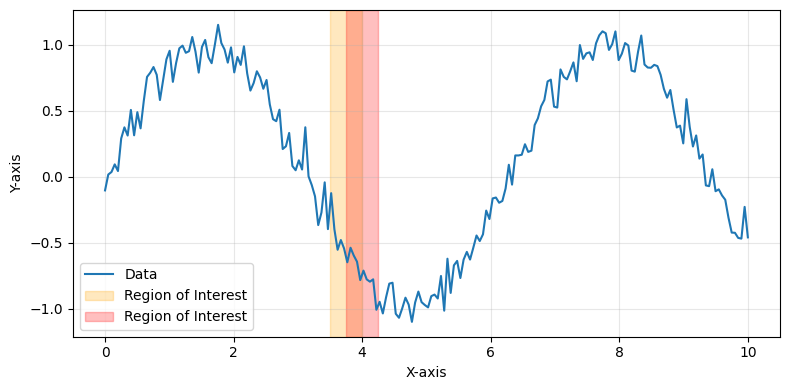

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt


# Sample data
x = np.linspace(0, 10, 200)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, linewidth=1.5, label='Data')

# Highlight vertical region from x=3 to x=5
ax.axvspan(3.5, 4.0, color='orange', alpha=0.25, label='Region of Interest')
ax.axvspan(3.75, 4.25, color='red', alpha=0.25, label='Region of Interest')

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
x

array([ 0.        ,  0.05025126,  0.10050251,  0.15075377,  0.20100503,
        0.25125628,  0.30150754,  0.35175879,  0.40201005,  0.45226131,
        0.50251256,  0.55276382,  0.60301508,  0.65326633,  0.70351759,
        0.75376884,  0.8040201 ,  0.85427136,  0.90452261,  0.95477387,
        1.00502513,  1.05527638,  1.10552764,  1.15577889,  1.20603015,
        1.25628141,  1.30653266,  1.35678392,  1.40703518,  1.45728643,
        1.50753769,  1.55778894,  1.6080402 ,  1.65829146,  1.70854271,
        1.75879397,  1.80904523,  1.85929648,  1.90954774,  1.95979899,
        2.01005025,  2.06030151,  2.11055276,  2.16080402,  2.21105528,
        2.26130653,  2.31155779,  2.36180905,  2.4120603 ,  2.46231156,
        2.51256281,  2.56281407,  2.61306533,  2.66331658,  2.71356784,
        2.7638191 ,  2.81407035,  2.86432161,  2.91457286,  2.96482412,
        3.01507538,  3.06532663,  3.11557789,  3.16582915,  3.2160804 ,
        3.26633166,  3.31658291,  3.36683417,  3.41708543,  3.46